# Comparing LDPC and CASCADE for LEO CubeSat GMCS CV-QKD: Progress Update


**Summary of what I've done so far:**

- Found an off-the-shelf implementation of the Cascade algorithm in cpp (cascade-cpp)[https://github.com/brunorijsman/cascade-cpp].

- Played around with both the CASCADE algorithm and LDPC algorithm, figuring out how the codebases are structured, how they run experiments, how the algorithms themselves work (and fit into the larger CV-QKD scheme) and what parameters each keeps track of.

- Cascade tracks a lot, LDPC not so much -> Implemented a (somewhat) equivalent parameter tracking system in LDPC (some parameters are not comparable/ do not exist due to the nature of the algorithms). Tried to verify both implementations of algorithms by remaking the graphs from publications (+ Graphs from Ed's December Progress update, for LDPC).

- Attempted to compare the algorithms over each parameter by sweeping SnR and key size, aiming to test their sensitivity and operating ranges.

**Summary of main findings:**

- The graphs show that the algorithms were designed/ are usable in completely different scenario's, they confirm what is expected in theory - LDPC works much better at lower SnR ranges (though this depends on the B-Matrix/Syndrome chosen) and CASCADE only really works at high SnR (low QBER), due to the many round trips that have to be made over the classical channel, for every error. In low SnR, there are so many errors that the number of round trips is much higher than the theoretical minimum defined by Shannon's entropy (how does this releate to mutual information I(A:B)) -> large number of reconciliation bits -> low efficiency -> does not even get close to the 98% reconciliation efficiency target.
- Cascade works (efficiency is reasonable) at QBER of 0.1 and below (corresponds to SnR of 0.75+) - LDPC ,with provided B-Matrices, works best at SnR of 0.xx (with efficiency 1.xx, which is just over the theoretical minimum). 
- Changing the Key rate shows ...
- Changing the SnR ...
- Changing the LDPC B-Matrix ...
- Changing the CASCADE iterations ...
- Worst case performance ...
- Include some numbers of interesting findings: efficiency, impact of latency(2 min pass duration - at what throughput would it suceed)?, CPU use/Power?

**Current state of things:** I can run both algorithms on my hardware, and produce plots of specific (tracked) parameters.

**Summary of what is tracked by Cascade-cpp**


```cpp
using namespace Cascade;

Stats::Stats():
    elapsed_process_time(0.0), // Actual thread CPU time (THREAD_CPUTIME_ID, doesn't include sleep or waiting for I/O time)
    elapsed_real_time(0.0), // Wall clock time - Real time (MONOTONIC - includes sleep time, waiting for I/O time etc.)
    normal_iterations(0), // Always 4 for original CASCADE
    biconf_iterations(0), // Number of BICONF iterations - 2 normal + up to 10 biconf iterations
    start_iteration_messages(0), // normal + biconf iterations - Number of messages sent (Total always 4 for original CASCADE)
    start_iteration_bits(0), // iteration number + seed summed over all iterations - see shuffle seed below.
    ask_parity_messages(0), // Number of round-trips, each message can contain many blocks.
    ask_parity_blocks(0), // number of blocks parity was asked for (total across all round-trips) - number of parity checks asked for.
    ask_parity_bits(0), // Number of bits parity was asked for (total across all round-trips) - 16 (header) + nr_blocks * 80 (parity bits)
    reply_parity_bits(0), // Number of bits parity was replied for (total across all round-trips) - 16 (header) + nr_blocks * 1 (parity bit)
    reconciliation_bits(0), // Total bits sent over classical channel: reconciliation_bits = start_iteration_bits + ask_parity_bits + reply_parity_bits
    efficiency(0.0), // Efficiency of the reconciliation process - reconciliation_bits / (key_size * shannon_efficiency)
    reconciliation_bits_per_key_bit(0.0), // Normalized overhead --- reconciliation_bits / key_size --- Classical communication overhead per key bit.
    infer_parity_blocks(0) // Number of blocks whose correct parity was inferred from parent and sibling parities instead of being asked from Alice.

    // SHUFFLE SEED: Original uses shuffle_seed (32 bits for iteration number + 64 for seed) or full shuffle (32 + 32 * shuffle->get_nr_bits() bits).
{
}
```

**The LDPC tracking implementation**

Developed in a new branch (`feature/stat-tracking`) of the `cvqkd-reconciliation` repository locally - I didn't get a chance to ask if I can push new branch to GitHub.

Results are serialised as **NDJSON** (Newline-Delimited JSON - one JSON object per line per operating point) matched to that of cascade-cpp to simplify cross-algorithm parsing. Statistics are accumulated over N independent frames using **Welford's online algorithm** (Welford, 1962), which computes a numerically stable running mean and variance in a single pass with O(1) memory per tracked metric. [https://en.wikipedia.org/wiki/Algorithms_for_calculating_variance#Welford%27s_online_algorithm] - TL;DR Cascade uses 'Naive one pass' method, both produce equivalent results, but Welford's is more stable numerically. 

Note: Cascade averages over N full-key runs, whereas LDPC averages over N frames, meaning sample counts can match directly but for the same statistical significance, we'd also have to match the key size (each LDPC frame depends on B-Matrix, e.g. 256 bits, whereas CASCADE usually works around 10,000 bits per run) - not sure if it's worth/viable packaging LDPC frames into a bigger frame? e.g. k = 4096 bits = 16 * 256 bit frames or if there is a better way to constrain/match the key size, maybe by applying some post_processing/ analytical approach... -> I decided to divide certain metrics by key_size and turn them into _per_key_bit so that both can operate around their optimal key sizes and still get a fair comparison!


`QKD_stats.c` - contains Welford helper functions. It also has a function to add an individual LDPC frames' stats into the aggregated welford counters, and print aggregated counters as NDJSON.

Here's a snippet of the stats I have implemented tracking for.

```c
        ...
        stats->algorithm_name, // Always 'LDPC'
        stats->key_size,
        stats->reconciliations, // Number of frames processed
        stats->snr,
        exec_time, // UTC timestamp of start of run
        stats->actual_bit_errors.mean,
            welford_deviation(&stats->actual_bit_errors),
        stats->actual_bit_error_rate.mean,
            welford_deviation(&stats->actual_bit_error_rate),
        stats->remaining_bit_errors.mean,
            welford_deviation(&stats->remaining_bit_errors),
        stats->remaining_bit_error_rate.mean,
            welford_deviation(&stats->remaining_bit_error_rate),
        stats->remaining_frame_error_rate.mean,
            welford_deviation(&stats->remaining_frame_error_rate),
        stats->elapsed_process_time.mean,
            welford_deviation(&stats->elapsed_process_time),
        stats->elapsed_real_time.mean,
            welford_deviation(&stats->elapsed_real_time),
        stats->normal_iterations.mean, // iterations of min-sum decoder used for each frame
            welford_deviation(&stats->normal_iterations),
        stats->reconciliation_bits.mean, // Syndrome size, usually constant for each B-Matrix
            welford_deviation(&stats->reconciliation_bits),
        stats->reconciliation_bits_per_key_bit.mean,
            welford_deviation(&stats->reconciliation_bits_per_key_bit),
        eff_avg, //Efficiency calculated the same way as CASCADE-CPP --- reconciliation_bits / (key_size * shannon_efficiency)
        eff_dev
    );
```


`ldpc_experiment.c` - experiment runner for running the full simulated GMCS CVQKD process with LDPC using `libqkd.c` and tracking relevant statistics using `QKD_stats.c`.

usage: `./build/ldpc_experiment <snr> <seed> <no. of frames to run> <B-Matrix path> <QKD dimension (defaults to 8)>`


**Verifying the correctness of both algorithms**

The main verification of correctness comes from comparing my graphs to that of widely known and publically accepted literature.

Cascade also has full unit-tests for testing the functionality of each component individually, LDPC has framework but no test implementations. (Might need to make some?)

### Cascade

Efficiency graph created via my workflow, matches the original cascade-cpp authors' graph, which matches that of popular Cascade literature - specifically Figure 1 from "Demystifying the Information Reconciliation Protocol Cascade"

#### My Efficiency Graph

Created with my workflow
Second graph is extended (up to 0.5 QBER, about 0 SNR) vs LDPC.

DOES NOT INCLUDE MODIFIED CASCADE (refer to question at the end about including all CASCADE variations)

![My Efficiency Graph](../graphs/VerificationCascadeOriginal0.png)
![My Efficiency Graph](../graphs/VerificationCascadeOriginalLDPC.png)
<!-- ![My Efficiency Graph Extended](../graphs/VerificationCascadeVs%20LDPC.png) -->

#### Cascade CPP author graph

Original Cascade efficiency (black line) in the QBER 0 - 0.1 matches up with my run (red line).

![cascade-cpp author graph](../graphs/cascadec_cpp_author_fig_1.png)

### Actual Figure 1 from 'Demystifying the IR Protocol Cascade'

![Demystifying the IR Protocol Cascade Figure 1](../graphs/Figure_1_demyst.png)

### LDPC

My 1-2*BER graph matches that of the original author (Ed).

(Why are we using this metric as a measure of performance over just BER?)


![1-2xBER Graph](../graphs/1-2xBER.png)

#### Ed's December Update Graph

![Ed's graph](../graphs/ed_ldpc_1-2xBER.png)


Not sure if matching to some literature is required/needed?

My xxx graph matches that of Figure x from "Some widely known LDPC literature"? I couldn't find some easily




## Comparison

**Summary of methodology when comparing them**

Since LDPC and CASCADE differ fundamentally in their communication model - one‑way syndrome transmission vs. interactive parity checks - they cannot be compared on strictly identical terms. However, as **information reconciliation** schemes within the same reverse‑reconciliation GMCS CV‑QKD framework, they share a common set of features: reconciliation efficiency η relative to the **Shannon limit** H(QBER) (binary entropy of the bit error rate), residual BER/FER after correction (currently doesn’t compare directly unless key_size matches - decided to turn stats into _per_key_bit, as does Comparing LDPC and CASCADE Muellar et al 2025), classical channel overhead (bits leaked per key bit), computational cost, and latency sensitivity. []

For a fair comparison, I treat the **pre‑correction bit error rate** (QBER) as the primary channel parameter that both algorithms must see in common. On the LDPC side, the experiment sweeps **SNR** over the range of interest for GMCS CV‑QKD (Currently 0.0001 to about 7.5 SNR); for each SNR point the full Gaussian channel + 8D multidimensional reconciliation (Leverrier–Grangier) pipeline is applied, and the resulting **actual_bit_error_rate** is measured empirically from the hard decisions on the LLRs. This measured `actual_bit_error_rate` is then taken as the *definition* of the operating‑point QBER for that SNR — I do **not** rely on the BPSK closed‑form formula to characterise the CV‑QKD channel, because the Gaussian + 8D mapping has a different BER–SNR relationship.

( I've had a quick look into the BPSK formula, QBER ≈ ½ · erfc(√SNR), but since it doesn't match the channel (gaussian + 8d rotation) I don't see it having any use case, it's scattered about in various parts of the project (mainly graphing). Will remove once I confirm it's not needed [https://www.salimwireless.com/2025/11/understanding-q-function-in-bpsk.html] )

On the CASCADE side, I run experiments over **requested_bit_error_rate** (binary symmetric channel) and then **match** those runs to the LDPC operating points by aligning on this measured QBER: for each LDPC SNR point with measured `actual_bit_error_rate`, I either (i) run CASCADE at the same requested bit error rate, or (ii) interpolate within a dense CASCADE QBER sweep to obtain metrics at the closest available QBER. When I plot “metric vs QBER”, the x‑axis is therefore always the **measured pre‑correction BER**: for LDPC this is `actual_bit_error_rate` after the Gaussian + 8D preprocessing; for CASCADE it is the requested / observed bit error rate of its binary symmetric channel.

Both algorithms are run N times per operating point (N frames for LDPC, N full reconciliations for CASCADE). For LDPC, Per-run statistics — mean and **sample** standard deviation — are accumulated online using **Welford's online algorithm** (Welford, 1962), which computes a numerically stable running mean and variance in a single pass with O(1) memory per tracked metric, avoiding the catastrophic cancellation that can arise in a one-pass/two-pass variance calculation at large N. Results are serialised as **NDJSON** (Newline-Delimited JSON), one object per operating point, in a format matched to that of cascade-cpp. CASCADE implementation relies on one-pass variance calculations that result in comparable mean and sample standard deviation statistics.

The LDPC decoder implements **Min-Sum decoding**, a low-complexity approximation of the **Sum-Product algorithm** (Belief Propagation on a Tanner graph). The 8D preprocessing step is the **Leverrier–Grangier multidimensional reconciliation** scheme (Leverrier et al., 2008), which maps Gaussian quadrature values to bits by selecting a unit hypercube corner; the post-rotation values serve as **log-likelihood ratios (LLRs)** for the Min-Sum decoder, where magnitude encodes reliability (soft information) and sign encodes the hard decision. CASCADE variants tested include the **original** (4 normal passes) + potential for others e.g. BICONF, option 7 etc.

[Write an equivalent description summary of CASCADE]

LDPC and CASCADE are always compared at **matched channel conditions** in terms of the actual pre‑correction BER they see, even though one is driven by SNR on a Gaussian CV‑QKD channel and the other by QBER on a binary symmetric channel. In other words, the actual methodology for comparing LDPC and CASCADE is based on **matching their performance at the same measured QBER**, with SNR kept explicitly for LDPC to preserve the CV‑QKD interpretation.

Note:
    - STD is much higher for LDPC because of the lower key size (LDPC performance is more variable per frame, CASCADE performance is more consistent per run.)

### Metrics that are comparable directly

#### Efficiency

`efficiency_avg / efficiency_std` 

Same formula for both: f = leaked_bits / (n · H(QBER)). 

Already normalised.

`Mueller et al. 2025` do  this in Figure 3.


![graph](../graphs/eff_1.png)

0.001 SNR is about 0.487 QBER in the LDPC Pipeline (Gaussian + 8d rotation), What's the target range we should be looking at for LEO CubeSat?

Why is efficiency < 1 for LDPC at very high QBER, very low SNR ?

-> `f = leaked_bits / n * Binary Entropy` Binary entropy is max at 0.5 QBER, == 1 -> So for 255x256 B matrix, syndrome len is fixed at 255 bits, so `f = 255 / 256 * 1 == approx 0.996`

![graph](../graphs/eff_2.png)

![graph](../graphs/eff_3.png)

![graph](../graphs/eff_4.png)

#### Actual Bit Error Rate

`actual_bit_error_rate_avg / _std` 

This measures the channel - It's a sanity check plot that shows that the operating points align.
It should be identical for both

![graph](../graphs/actual_bit_error_rate.png)

#### Reamaining Bit Error Rate

`remaining_bit_error_rate_avg / _std` Already normalised, both should approach zero at their respective operating ranges.

![graph](../graphs/remaining_ber.png)


![graph](../graphs/remaining_ber_2.png)

#### Reconciliation Bits Per Key Bit / Reconciliation Bits

`reconciliation_bits_per_key_bit_avg / _std Already normalised per key bit.` 
`Mueller et al. 2025` do  this in Figure 4.

LDPC is `255/256`, `1023/1024`, `2044/2048` reconciliation bits per key bit.

![graph](../graphs/recon_bits_per_key_bit.png)

`reconciliation_bits_avg` graph for completeness, a little pointless since key_size is 10,000

![graph](../graphs/recon_bits.png)


###  Metrics that need to be divided by key_size

LDPC processes 256 bits per frame, CASCADE processes 10,000 bits per run.

Elapsed process and real times are normalised to `µs per key bit = elapsed_time / key_size`

#### Elapsed Process Time

`elapsed_process_time_avg`

![graph](../graphs/process_time_1.png)

![graph](../graphs/process_time_2.png)

#### Elapsed Real Time

`elapsed_real_time_avg`

![graph](../graphs/real_time_1.png)

![graph](../graphs/real_time_2.png)

### Special Case: Frame Error Rate (FER)

Mueller et al. handle this through their fFER metric (Equation 5 in the paper), which folds FER into the efficiency:
f_FER = (1 - FER) · f + FER / H(q)

Mention BER and FER about LDPC - We want to keep FER high at low SNR/high QBER so that the decoder does not "successfully" decode random noise, but at the target SNR we want to keep FER low, so that it successfully decodes/converges. Why does this not match up with Ed's December update graph? Surely you want to maximise FER when you have only noise, and minimise FER where you have signal?

[Graph]


### Constraints Modelling for LEO CubeSat

List constraints, and justification. Maybe explain model.

- LEO Pass = Constant SNR?

- Low CPU power/ limited processing on CubeSat (Q8 Xiphos)

- Limited memory on CubeSat? (Ask Killian)

- Classical Channel Bandwidth (rate-limited, downlink is X band, uplink is S band)

- Limited pass duration (how many minutes)? - 2 minutes, maybe treat it as power.

- Reconciliation Efficiency target? 98% would be best case

- Network Latency (using one-way, one classical message LDPC)
LDPC reconciliation is modelled as a one‑way reverse‑reconciliation protocol: Bob transmits a single block of side information per frame (multidimensional reconciliation data + LDPC syndrome), and Alice performs iterative decoding locally; no additional classical interaction is required. In a 2 Min pass, this may result in multiple messages.


### Feasibility Matrix

Worth completing it for the other variations? 

### Next steps

- Compare the variations of CASCADE? None of them have a reasonable efficiency at target LEO SNR. I know there exists a variation that does have a good efficiency up to 0.5 QBER [This implementation is used in the 2025 comparison between LDPC and CASCADE, which references a publication from 2015 explainaing the algorithm, which is a direct improvement upon the pulibcation `Demystifying the IR protocol CASCADE` which cascade-cpp bases its implementations on] - but it is not implemented in cascade-cpp (I believe closest one is option 7) Show which is feasible at which SNR range for LEO scenario?

- Run on real hardware?

- What to do with B-Matrices, which ones to compare?

- Can I commit branch to GitHub?

- More thorough computational / memory comparison ?

- Make CASCADE use key_size power of 2, reference comparing publication.

- What to do next? Need to keep in mind I only have a few weeks left to write up and submit final report at the end of April.


### Comparing FER and BER

Assuming we don't change the key size ... LDPC FER = P(any error in 256 bits). CASCADE FER = P(any error in 10,000 bits). At the same underlying BER, CASCADE will always have higher FER purely because the key is longer - more bits means more chances for one to survive incorrectly. So need to match Key too?

For FER — potentially use the analytical projection approach:
Rather than grouping frames and dropping them, compute the implied whole-key FER analytically from the per-frame FER. If you have a target key length K (e.g. 10,000 bits), the probability that all LDPC frames are clean is:
FER_key(K) = 1 − (1 − FER_frame)^(K / 256)
This gives you a directly comparable "FER for a key of length K" without running artificial grouping experiments. You can overlay this derived curve on the same plot as CASCADE's FER at key_size=K. It also has a clean physical interpretation — it's exactly the probability that error correction fails somewhere in a full QKD reconciliation round.
Optionally, one direct FER cross-check:
Run CASCADE at key_size=256 for one plot specifically, just to validate that the analytical projection is consistent. CASCADE can run at small key sizes (it just becomes inefficient, which is fine since you're only using it to sanity-check the FER model, not claiming it's a good configuration).



### Comparing messages sent over the Classical channel/ Leakage

Cascade - `ask_parity_bits` refers to Number of bits parity was asked for, `reply_parity_bits` refers to Number of bits parity was replied for, `reconciliation_bits` refers to total bits sent over classical channel and `reconciliation_bits_per_key_bit` is a normalized overhead (number of bits sent over the classical channel) per key bit sent.

LDPC - always sends a fixed size syndrome and does not expect a response, unless it is a hash/ checksum? depends on algorithm, in this case we assume ... WHAT DO I ASSUME

The one genuinely useful re-run would be computing ask_parity_messages for CASCADE at various key sizes to build the latency model — but you likely already have that in your CASCADE data. The Mueller et al. Figure 4 (messages per corrected bit vs frame size) is worth reproducing as a standalone plot showing why small LDPC frames are problematic for latency, even if they're computationally cheap.

### Comparing iterations

Iterations in Cascade refers to ... (They are always set to 4)

Iterations in LDPC refers to ... (vary based on difficulty of syndrome/ likelihood values)

### Comparing CPU time/ Wall Clock time

CPU time means...

Wall Clock time means...


### Comparing Memory Usage




### How to compare the throughput?

Energy estimates?

Feasibility?

How many bits we get per pass?


In [474]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy import special

In [475]:
file_path = "../data/raw/snr_sweep_0_to_7_5_1000frames_per_point.ndjson"

data = []
with open(file_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

df.head(3)

,algorithm_name,key_size,reconciliations,snr,execution_time,actual_bit_errors,actual_bit_error_rate,remaining_bit_errors,remaining_bit_error_rate,remaining_frame_error_rate,elapsed_process_time,elapsed_real_time,normal_iterations,reconciliation_bits,reconciliation_bits_per_key_bit,efficiency
0,ldpc,256,10000,0.000100,2026-03-12 10:31:37 UTC,"{'average': 126.991, 'deviation': 7.920285}","{'average': 0.496059, 'deviation': 0.030939}","{'average': 63.3036, 'deviation': 70.581622}","{'average': 0.24728, 'deviation': 0.275709}","{'average': 0.4458, 'deviation': 0.497054}","{'average': 0.000163, 'deviation': 2.6e-05}","{'average': 0.000164, 'deviation': 2.7e-05}","{'average': 5.9914, 'deviation': 1.099785}","{'average': 255.0, 'deviation': 0.0}","{'average': 0.996094, 'deviation': 0.0}","{'average': 0.998919, 'deviation': 0.004018}"
1,ldpc,256,10000,0.000110,2026-03-12 10:31:40 UTC,"{'average': 126.9397, 'deviation': 7.919966}","{'average': 0.495858, 'deviation': 0.030937}","{'average': 62.9486, 'deviation': 70.542008}","{'average': 0.245893, 'deviation': 0.275555}","{'average': 0.4433, 'deviation': 0.496775}","{'average': 0.000164, 'deviation': 2.6e-05}","{'average': 0.000164, 'deviation': 2.7e-05}","{'average': 5.9907, 'deviation': 1.100279}","{'average': 255.0, 'deviation': 0.0}","{'average': 0.996094, 'deviation': 0.0}","{'average': 0.998923, 'deviation': 0.004033}"
2,ldpc,256,10000,0.000121,2026-03-12 10:31:43 UTC,"{'average': 126.8904, 'deviation': 7.924203}","{'average': 0.495666, 'deviation': 0.030954}","{'average': 62.5794, 'deviation': 70.49889}","{'average': 0.244451, 'deviation': 0.275386}","{'average': 0.4407, 'deviation': 0.496471}","{'average': 0.000165, 'deviation': 3.1e-05}","{'average': 0.000167, 'deviation': 8.8e-05}","{'average': 5.9907, 'deviation': 1.099461}","{'average': 255.0, 'deviation': 0.0}","{'average': 0.996094, 'deviation': 0.0}","{'average': 0.998931, 'deviation': 0.00405}"


In [476]:
def extract_metric(df, metric):
    df[f"{metric}_avg"] = df[metric].apply(lambda x: x["average"])
    df[f"{metric}_std"] = df[metric].apply(lambda x: x["deviation"])
    return df

metrics = [
    "actual_bit_error_rate",
    "remaining_bit_error_rate",
    "remaining_frame_error_rate",
    "efficiency",
    "elapsed_process_time",
    "elapsed_real_time",
    "normal_iterations",
    "reconciliation_bits",
    "reconciliation_bits_per_key_bit"
]

for m in metrics:
    df = extract_metric(df, m)

df = df.sort_values(by=["key_size", "snr"])
df.head()

,algorithm_name,key_size,reconciliations,snr,execution_time,actual_bit_errors,actual_bit_error_rate,remaining_bit_errors,remaining_bit_error_rate,remaining_frame_error_rate,...,elapsed_process_time_avg,elapsed_process_time_std,elapsed_real_time_avg,elapsed_real_time_std,normal_iterations_avg,normal_iterations_std,reconciliation_bits_avg,reconciliation_bits_std,reconciliation_bits_per_key_bit_avg,reconciliation_bits_per_key_bit_std
0,ldpc,256,10000,0.000100,2026-03-12 10:31:37 UTC,"{'average': 126.991, 'deviation': 7.920285}","{'average': 0.496059, 'deviation': 0.030939}","{'average': 63.3036, 'deviation': 70.581622}","{'average': 0.24728, 'deviation': 0.275709}","{'average': 0.4458, 'deviation': 0.497054}",...,0.000163,0.000026,0.000164,0.000027,5.9914,1.099785,255.0,0.0,0.996094,0.0
1,ldpc,256,10000,0.000110,2026-03-12 10:31:40 UTC,"{'average': 126.9397, 'deviation': 7.919966}","{'average': 0.495858, 'deviation': 0.030937}","{'average': 62.9486, 'deviation': 70.542008}","{'average': 0.245893, 'deviation': 0.275555}","{'average': 0.4433, 'deviation': 0.496775}",...,0.000164,0.000026,0.000164,0.000027,5.9907,1.100279,255.0,0.0,0.996094,0.0
2,ldpc,256,10000,0.000121,2026-03-12 10:31:43 UTC,"{'average': 126.8904, 'deviation': 7.924203}","{'average': 0.495666, 'deviation': 0.030954}","{'average': 62.5794, 'deviation': 70.49889}","{'average': 0.244451, 'deviation': 0.275386}","{'average': 0.4407, 'deviation': 0.496471}",...,0.000165,0.000031,0.000167,0.000088,5.9907,1.099461,255.0,0.0,0.996094,0.0
3,ldpc,256,10000,0.000133,2026-03-12 10:31:46 UTC,"{'average': 126.8378, 'deviation': 7.926417}","{'average': 0.49546, 'deviation': 0.030963}","{'average': 62.2386, 'deviation': 70.457348}","{'average': 0.24312, 'deviation': 0.275224}","{'average': 0.4383, 'deviation': 0.496179}",...,0.000165,0.000031,0.000168,0.000081,5.9885,1.097983,255.0,0.0,0.996094,0.0
4,ldpc,256,10000,0.000146,2026-03-12 10:31:49 UTC,"{'average': 126.7796, 'deviation': 7.927094}","{'average': 0.495233, 'deviation': 0.030965}","{'average': 61.9404, 'deviation': 70.419625}","{'average': 0.241955, 'deviation': 0.275077}","{'average': 0.4362, 'deviation': 0.495913}",...,0.000164,0.000027,0.000165,0.000028,5.9857,1.096675,255.0,0.0,0.996094,0.0


In [477]:
# Load Cascade results for LDPC comparison (run: cd cascade-cpp && make data-snr-sweep-ldpc-compare)
# Error rate -> SNR mapping (from LDPC at 0.0001-0.1; BPSK for 0.5, 1, 2) REMEMBER TO MAP 0.5, 1, 2 FROM LDPC 
ERROR_RATE_TO_SNR = {0.497: 0.0001, 0.489: 0.001, 0.463: 0.01, 0.382: 0.1, 0.159: 0.5, 0.079: 1.0, 0.023: 2.0}

def _err_to_snr(err):
    """Map error rate to SNR. Exact match first, else closest key, else BPSK estimate."""
    r = round(err, 3)
    if r in ERROR_RATE_TO_SNR:
        return ERROR_RATE_TO_SNR[r]
    for k, v in ERROR_RATE_TO_SNR.items():
        if abs(k - err) < 0.01:
            return v
    # BPSK: BER = Q(sqrt(2*SNR)) => SNR = erfcinv(2*BER)^2
    from scipy import special
    ber = max(1e-10, min(1 - 1e-10, err))
    return float(special.erfcinv(2 * ber) ** 2)

def load_cascade_snr_sweep(data_dir):
    """Load Cascade experiment results and map to SNR for comparison with LDPC."""
    from pathlib import Path
    cascade_data = []
    for p in Path(data_dir).glob("data__*"):
        if p.is_file():
            with open(p) as f:
                for line in f:
                    if line.strip():
                        row = json.loads(line)
                        err = row["requested_bit_error_rate"]
                        row["snr"] = _err_to_snr(err)
                        cascade_data.append(row)
    if not cascade_data:
        print(f"No Cascade data found in {data_dir}. Run: cd cascade-cpp && make data-snr-sweep-ldpc-compare")
        return None
    df_cascade = pd.DataFrame(cascade_data)
    for m in ["actual_bit_error_rate", "remaining_bit_error_rate", "remaining_frame_error_rate",
              "efficiency", "elapsed_real_time", "normal_iterations", "reconciliation_bits",
              "reconciliation_bits_per_key_bit"]:
        if m in df_cascade.columns:
            df_cascade[f"{m}_avg"] = df_cascade[m].apply(lambda x: x["average"] if isinstance(x, dict) else x)
            df_cascade[f"{m}_std"] = df_cascade[m].apply(lambda x: x["deviation"] if isinstance(x, dict) else 0)
    df_cascade = df_cascade.sort_values(by=["key_size", "snr"])
    return df_cascade

df_cascade = load_cascade_snr_sweep("../../cascade-cpp/study/data/snr_sweep_ldpc_compare")
df_cascade_verification = load_cascade_snr_sweep("../../cascade-cpp/study/data/verification")
df_cascade_verification_extended = load_cascade_snr_sweep("../../cascade-cpp/study/data/verification_extended")
if df_cascade is not None:
    print("Cascade data loaded. Use df_cascade for Cascade-only plots, or pd.concat([df, df_cascade]) for combined.")
    df_cascade.head()
if df_cascade_verification is not None:
    print("Cascade verification data loaded. Use df_cascade_verification for Cascade-only plots, or pd.concat([df, df_cascade_verification]) for combined.")
    df_cascade_verification.head()
if df_cascade_verification_extended is not None:
    print("Cascade verification extended data loaded. Use df_cascade_verification_extended for Cascade-only plots, or pd.concat([df, df_cascade_verification_extended]) for combined.")
    df_cascade_verification_extended.shape


Cascade data loaded. Use df_cascade for Cascade-only plots, or pd.concat([df, df_cascade]) for combined.
Cascade verification data loaded. Use df_cascade_verification for Cascade-only plots, or pd.concat([df, df_cascade_verification]) for combined.
Cascade verification extended data loaded. Use df_cascade_verification_extended for Cascade-only plots, or pd.concat([df, df_cascade_verification_extended]) for combined.


In [478]:
for m in metrics:
    df_cascade = extract_metric(df_cascade, m)
    df_cascade_verification = extract_metric(df_cascade_verification, m)
    df_cascade_verification_extended = extract_metric(df_cascade_verification_extended, m)

df_cascade = df_cascade.sort_values(by=["key_size", "snr"])

df_cascade_verification.head()

,actual_bit_error_rate,actual_bit_errors,algorithm_name,ask_parity_bits,ask_parity_blocks,ask_parity_messages,biconf_iterations,elapsed_process_time,elapsed_real_time,execution_time,...,elapsed_real_time_avg,elapsed_real_time_std,normal_iterations_avg,normal_iterations_std,reconciliation_bits_avg,reconciliation_bits_std,reconciliation_bits_per_key_bit_avg,reconciliation_bits_per_key_bit_std,elapsed_process_time_avg,elapsed_process_time_std
310,"{'average': 0.1095, 'deviation': 0.0}","{'average': 1095.0, 'deviation': 0.0}",original,"{'average': 495752.0464, 'deviation': 1644.796...","{'average': 6189.9569, 'deviation': 20.531917}","{'average': 34.7184, 'deviation': 6.549824}","{'average': 0.0, 'deviation': 0.0}","{'average': 0.001502, 'deviation': 2.7e-05}","{'average': 0.001504, 'deviation': 3e-05}",2026-03-10 18:43:46 GMT,...,0.001504,0.000030,4.0,0.0,502881.4977,1674.060232,50.288150,0.167406,0.001502,0.000027
309,"{'average': 0.109, 'deviation': 0.0}","{'average': 1090.0, 'deviation': 0.0}",original,"{'average': 494422.7504, 'deviation': 1646.336...","{'average': 6173.4005, 'deviation': 20.522242}","{'average': 34.4194, 'deviation': 6.362936}","{'average': 0.0, 'deviation': 0.0}","{'average': 0.001498, 'deviation': 2.7e-05}","{'average': 0.001499, 'deviation': 3e-05}",2026-03-10 18:43:26 GMT,...,0.001499,0.000030,4.0,0.0,501530.8613,1677.516126,50.153086,0.167752,0.001498,0.000027
308,"{'average': 0.1085, 'deviation': 0.0}","{'average': 1085.0, 'deviation': 0.0}",original,"{'average': 493127.4144, 'deviation': 1623.708...","{'average': 6157.2563, 'deviation': 20.248743}","{'average': 34.1819, 'deviation': 6.38278}","{'average': 0.0, 'deviation': 0.0}","{'average': 0.001493, 'deviation': 2.9e-05}","{'average': 0.001496, 'deviation': 8.8e-05}",2026-03-10 18:43:05 GMT,...,0.001496,0.000088,4.0,0.0,500215.5811,1653.995912,50.021558,0.165400,0.001493,0.000029
307,"{'average': 0.108, 'deviation': 0.0}","{'average': 1080.0, 'deviation': 0.0}",original,"{'average': 491829.8896, 'deviation': 1643.833...","{'average': 6141.0655, 'deviation': 20.479003}","{'average': 34.0406, 'deviation': 6.327966}","{'average': 0.0, 'deviation': 0.0}","{'average': 0.001489, 'deviation': 2.7e-05}","{'average': 0.001491, 'deviation': 8e-05}",2026-03-10 18:42:44 GMT,...,0.001491,0.000080,4.0,0.0,498899.6047,1675.858896,49.889960,0.167586,0.001489,0.000027
306,"{'average': 0.1075, 'deviation': 0.0}","{'average': 1075.0, 'deviation': 0.0}",original,"{'average': 490554.0432, 'deviation': 1622.368...","{'average': 6125.1293, 'deviation': 20.226969}","{'average': 33.9812, 'deviation': 6.318009}","{'average': 0.0, 'deviation': 0.0}","{'average': 0.001485, 'deviation': 4.3e-05}","{'average': 0.001495, 'deviation': 0.000265}",2026-03-10 18:42:24 GMT,...,0.001495,0.000265,4.0,0.0,497606.8717,1652.911262,49.760687,0.165291,0.001485,0.000043


In [479]:
# def plot_metric(df, metric_name, ylabel):
#     plt.figure(figsize=(8,6))

#     for key_size, group in df.groupby("key_size"):
#         plt.plot(
#             group["snr"],
#             group[f"{metric_name}_avg"],
#             marker=None,
#             label=f"N = {key_size}"
#         )

#     plt.xscale("log")
#     plt.xlabel("SNR")
#     plt.ylabel(ylabel)
#     ax = plt.gca()
#     tick_positions = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 7.5, 10.0]
#     ax.xaxis.set_major_locator(ticker.FixedLocator(tick_positions))
#     ax.xaxis.set_major_formatter(ticker.FixedFormatter(["0.0001", "0.001", "0.01", "0.1", "0.5", "1.0", "2.0", "5.0", "7.5", "10.0"]))
#     # plt.ylim(0, 1)
#     # plt.ylim(0.9, 1.4)
#     # plt.xlim(0, 2)
#     ax.set_yticks([1.0, 1.1, 1.2, 1.3])
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [480]:
# ── SNR ↔ QBER conversions ───────────────────────────────────────────────────
def snr_to_qber(snr):
    """QBER ≈ ½·erfc(√SNR)  (BPSK - not Gaussian Channel, 8D multidimensional reconciliation)."""
    return 0.5 * special.erfc(np.sqrt(np.asarray(snr, dtype=float)))

def qber_to_snr(qber):
    """Inverse: SNR = [erfcinv(2·QBER)]²."""
    return special.erfcinv(2 * np.asarray(qber, dtype=float)) ** 2


# ── Internal helpers ──────────────────────────────────────────────────────────
_LINE_STYLES = ["-", "--", "-.", ":"]

def _get_colors(n):
    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return [cycle[i % len(cycle)] for i in range(n)]

def _build_keysize_color_map(series_list):
    """Assign a consistent color to each unique key_size across all series."""
    all_key_sizes = sorted({ks for df, _ in series_list for ks in df["key_size"].unique()})
    colors = _get_colors(len(all_key_sizes))
    return {ks: c for ks, c in zip(all_key_sizes, colors)}

def _draw_series(ax, x, grp, metric, label, color, show_band, linestyle="-", marker='o'):
    y_avg = grp[f"{metric}_avg"].values
    ax.plot(x, y_avg, marker=marker, markersize=3, linewidth=1.5,
            label=label, color=color, linestyle=linestyle)
    if show_band and f"{metric}_std" in grp.columns:
        y_std = grp[f"{metric}_std"].values
        ax.fill_between(x, np.maximum(0, y_avg - y_std), y_avg + y_std, alpha=0.15, color=color)

def _get_x_snr(grp):
    """Return sorted SNR values and the correspondingly sorted group (index reset)."""
    grp = grp.reset_index(drop=True)
    x = grp["snr"].values
    idx = np.argsort(x)
    return x[idx], grp.iloc[idx].reset_index(drop=True)

def _get_x_qber(grp):
    """Derive QBER from snr column and return sorted values + sorted group (index reset)."""
    grp = grp.reset_index(drop=True)
    x = snr_to_qber(grp["snr"].values)
    idx = np.argsort(x)
    return x[idx], grp.iloc[idx].reset_index(drop=True)

def _series_label(base_label, key_size, n_key_sizes):
    """Include N= only when there are multiple key sizes in the frame."""
    return f"{base_label}  (N={key_size})" if n_key_sizes > 1 else base_label

def _finalise(ax, xlabel, ylabel, title, ylim):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend()
    plt.tight_layout()
    plt.show()


def _get_x_qber_from_actual_ber(grp):
    """Use measured pre‑correction BER as QBER on the x-axis.

    Works for both:
      - aggregated stats with 'actual_bit_error_rate_avg', or
      - flat data with 'actual_bit_error_rate'.
    """
    grp = grp.reset_index(drop=True)
    if "actual_bit_error_rate_avg" in grp.columns:
        x = grp["actual_bit_error_rate_avg"].values
    elif "actual_bit_error_rate" in grp.columns:
        x = grp["actual_bit_error_rate"].values
    else:
        raise KeyError(
            "_get_x_qber_from_actual_ber expects "
            "'actual_bit_error_rate_avg' or 'actual_bit_error_rate' in the DataFrame."
        )
    idx = np.argsort(x)
    return x[idx], grp.iloc[idx].reset_index(drop=True)


# ── The three plot functions ──────────────────────────────────────────────────

def plot_vs_qber(series_list, metric, ylabel,
                 qber_range=(0.00, 0.10), title=None,
                 ylim=None, show_band=True, figsize=(8, 5),
                 color_by_keysize=False, marker='o'):
    """
    Plot *metric* on a linear QBER x-axis (0.00 – 0.10).

    Parameters
    ----------
    series_list : list of (df, label)
        Each df must have either 'actual_bit_error_rate_avg' or 'actual_bit_error_rate'
        plus {metric}_avg / {metric}_std.
        QBER is taken as the measured pre‑correction bit error rate for each row.
    metric         : column stem, e.g. "efficiency"
    ylabel         : y-axis label
    qber_range     : (lo, hi) x-axis limits
    ylim           : (lo, hi) y-axis limits, or None for auto
    show_band      : draw ±1σ shaded band
    color_by_keysize : if True, color lines by key_size (linestyle distinguishes series)
    """
    fig, ax = plt.subplots(figsize=figsize)
    series_colors = _get_colors(len(series_list))
    ks_color_map = _build_keysize_color_map(series_list) if color_by_keysize else {}

    for i, ((df, label), series_color) in enumerate(zip(series_list, series_colors)):
        n_ks = df["key_size"].nunique()
        ls = _LINE_STYLES[i % len(_LINE_STYLES)] if color_by_keysize else "-"
        for key_size, grp in df.groupby("key_size"):
            # x, grp_s = _get_x_qber(grp)
            x, grp_s = _get_x_qber_from_actual_ber(grp)
            mask = (x >= qber_range[0]) & (x <= qber_range[1])
            x, grp_s = x[mask], grp_s[mask]
            if len(x) == 0:
                continue
            color = ks_color_map[key_size] if color_by_keysize else series_color
            lbl = f"{label} (N={key_size})" if color_by_keysize else _series_label(label, key_size, n_ks)
            _draw_series(ax, x, grp_s, metric, lbl, color, show_band, linestyle=ls, marker=marker)

    ax.set_xlim(qber_range)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    _finalise(ax, "QBER", ylabel, title, ylim)


def plot_vs_snr_linear(series_list, metric, ylabel,
                       snr_range=(0.0, 2.0), title=None,
                       ylim=None, show_band=True, figsize=(8, 5),
                       color_by_keysize=False):
    """
    Plot *metric* on a linear SNR x-axis.

    Parameters
    ----------
    snr_range        : (lo, hi) x-axis limits  (linear scale)
    color_by_keysize : if True, color lines by key_size (linestyle distinguishes series)
    """
    fig, ax = plt.subplots(figsize=figsize)
    series_colors = _get_colors(len(series_list))
    ks_color_map = _build_keysize_color_map(series_list) if color_by_keysize else {}

    for i, ((df, label), series_color) in enumerate(zip(series_list, series_colors)):
        n_ks = df["key_size"].nunique()
        ls = _LINE_STYLES[i % len(_LINE_STYLES)] if color_by_keysize else "-"
        for key_size, grp in df.groupby("key_size"):
            x, grp_s = _get_x_snr(grp)
            mask = (x >= snr_range[0]) & (x <= snr_range[1])
            x, grp_s = x[mask], grp_s[mask]
            if len(x) == 0:
                continue
            color = ks_color_map[key_size] if color_by_keysize else series_color
            lbl = f"{label} (N={key_size})" if color_by_keysize else _series_label(label, key_size, n_ks)
            _draw_series(ax, x, grp_s, metric, lbl, color, show_band, linestyle=ls)

    ax.set_xlim(snr_range)
    _finalise(ax, "SNR", ylabel, title, ylim)


# Default log-scale tick positions (expanded towards zero)
_SNR_LOG_TICKS = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]

def plot_vs_snr_log(series_list, metric, ylabel,
                    snr_ticks=None, title=None,
                    ylim=None, show_band=True, figsize=(8, 5),
                    color_by_keysize=False):
    """
    Plot *metric* on a log SNR x-axis, expanded towards zero.

    Default ticks: 0.0001, 0.001, 0.01, 0.1, 0.5, 1.0
    Pass snr_ticks=[...] to override.

    color_by_keysize : if True, color lines by key_size (linestyle distinguishes series)
    """
    ticks = snr_ticks if snr_ticks is not None else _SNR_LOG_TICKS
    fig, ax = plt.subplots(figsize=figsize)
    series_colors = _get_colors(len(series_list))
    ks_color_map = _build_keysize_color_map(series_list) if color_by_keysize else {}

    for i, ((df, label), series_color) in enumerate(zip(series_list, series_colors)):
        n_ks = df["key_size"].nunique()
        ls = _LINE_STYLES[i % len(_LINE_STYLES)] if color_by_keysize else "-"
        for key_size, grp in df.groupby("key_size"):
            x, grp_s = _get_x_snr(grp)
            mask = (x >= ticks[0]) & (x <= ticks[-1])
            x, grp_s = x[mask], grp_s[mask]
            if len(x) == 0:
                continue
            color = ks_color_map[key_size] if color_by_keysize else series_color
            lbl = f"{label} (N={key_size})" if color_by_keysize else _series_label(label, key_size, n_ks)
            _draw_series(ax, x, grp_s, metric, lbl, color, show_band, linestyle=ls)

    ax.set_xscale("log")
    ax.xaxis.set_major_locator(ticker.FixedLocator(ticks))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter([str(t) for t in ticks]))
    _finalise(ax, "SNR (log scale)", ylabel, title, ylim)


# ── Usage examples ────────────────────────────────────────────────────────────
# plot_vs_qber(
#     [(df, "LDPC"), (df_cascade, "CASCADE biconf")],
#     metric="efficiency", ylabel="Reconciliation Efficiency η",
#     ylim=(0.9, 2.0), title="Efficiency vs QBER"
# )
#
# plot_vs_snr_linear(
#     [(df, "LDPC"), (df_cascade, "CASCADE biconf")],
#     metric="efficiency", ylabel="Reconciliation Efficiency η",
#     snr_range=(0.0, 2.0)
# )
#
# plot_vs_snr_log(
#     [(df, "LDPC"), (df_cascade, "CASCADE biconf")],
#     metric="remaining_frame_error_rate", ylabel="Frame Error Rate (FER)"
# )


In [481]:
df_cascade_verification.columns

Index(['actual_bit_error_rate', 'actual_bit_errors', 'algorithm_name',
       'ask_parity_bits', 'ask_parity_blocks', 'ask_parity_messages',
       'biconf_iterations', 'elapsed_process_time', 'elapsed_real_time',
       'execution_time', 'infer_parity_blocks', 'key_size',
       'normal_iterations', 'reconciliation_bits',
       'reconciliation_bits_per_key_bit', 'reconciliations',
       'remaining_bit_error_rate', 'remaining_bit_errors',
       'remaining_frame_error_rate', 'reply_parity_bits',
       'requested_bit_error_rate', 'efficiency', 'snr',
       'actual_bit_error_rate_avg', 'actual_bit_error_rate_std',
       'remaining_bit_error_rate_avg', 'remaining_bit_error_rate_std',
       'remaining_frame_error_rate_avg', 'remaining_frame_error_rate_std',
       'efficiency_avg', 'efficiency_std', 'elapsed_real_time_avg',
       'elapsed_real_time_std', 'normal_iterations_avg',
       'normal_iterations_std', 'reconciliation_bits_avg',
       'reconciliation_bits_std', 'reconciliat

In [482]:
df["real_time_per_bit_avg"] = df["elapsed_real_time_avg"] / df["key_size"]
df["process_time_per_bit_avg"] = df["elapsed_process_time_avg"] / df["key_size"]

df_cascade_verification_extended["real_time_per_bit_avg"] = df_cascade_verification_extended["elapsed_real_time_avg"] / df_cascade_verification_extended["key_size"]
df_cascade_verification_extended["process_time_per_bit_avg"] = df_cascade_verification_extended["elapsed_process_time_avg"] / df_cascade_verification_extended["key_size"]


In [467]:
# df_cascade_verification_extended.columns

# df_cascade_verification_extended[["requested_bit_error_rate", "actual_bit_error_rate_avg"]].describe()
# # df_cascade_verification_extended[["requested_bit_error_rate", "actual_bit_error_rate_avg"]].tail(10)


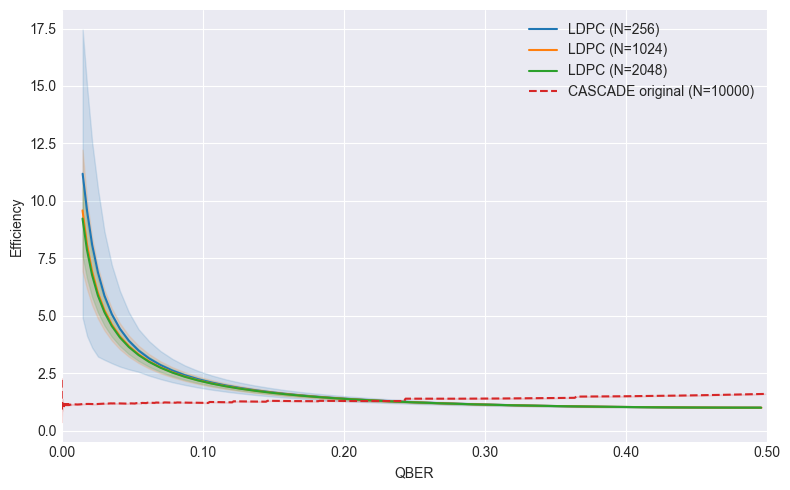

In [ ]:
# df = df_cascade_verification_extended

# high = df[df["actual_bit_error_rate_avg"] > 0.22][
#     ["requested_bit_error_rate", "actual_bit_error_rate_avg", "real_time_per_bit_avg", "elapsed_real_time_avg", "elapsed_process_time_avg", "key_size"]
# ]
# high.head(10), high.tail(10)

plot_vs_qber(
    [(df, "LDPC"), (df_cascade_verification_extended, "CASCADE original")],
    metric='efficiency',
    ylabel='Efficiency',
    qber_range=(0.00, 0.5),
    color_by_keysize=True,
    show_band=True,
    marker=None,
)

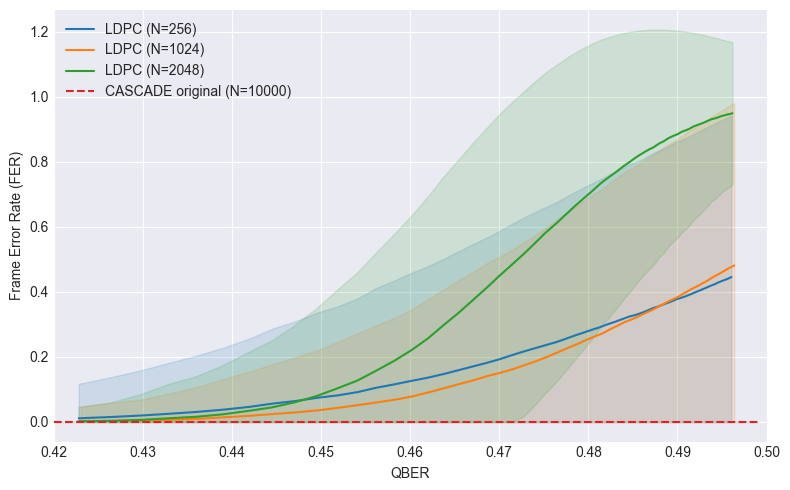

In [512]:
plot_vs_qber(
    [(df, "LDPC"), (df_cascade_verification_extended, "CASCADE original")],
    metric='remaining_frame_error_rate',
    ylabel='Frame Error Rate (FER)',
    qber_range=(0.42, 0.5),
    color_by_keysize=True,
    show_band=True,
    marker=None,
)

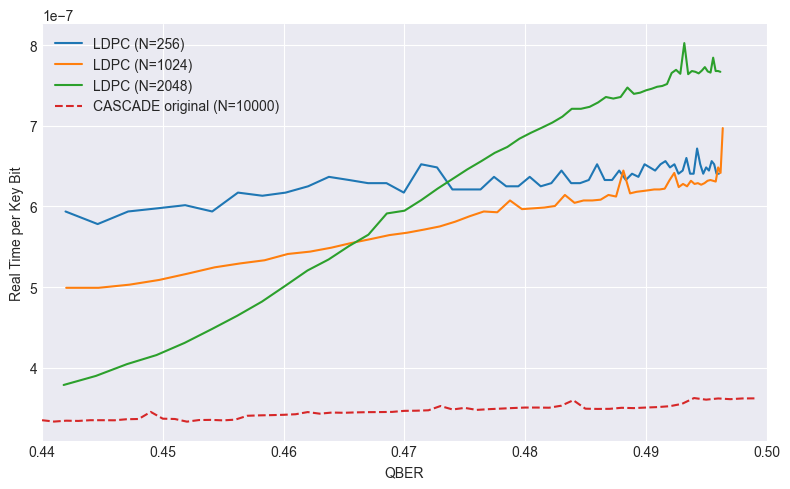

In [486]:
# df_cascade_original = df_cascade[df_cascade["algorithm_name"] == "original"]
# df_cascade_original.shape
# plot_metric(df_cascade_original, "efficiency", "Efficiency")

plot_vs_qber(
    [(df, "LDPC"), (df_cascade_verification_extended, "CASCADE original")],
    metric='real_time_per_bit',
    ylabel='Real Time per Key Bit',
    qber_range=(0.44, 0.5),
    color_by_keysize=True,
    show_band=False,
    marker=None,
)


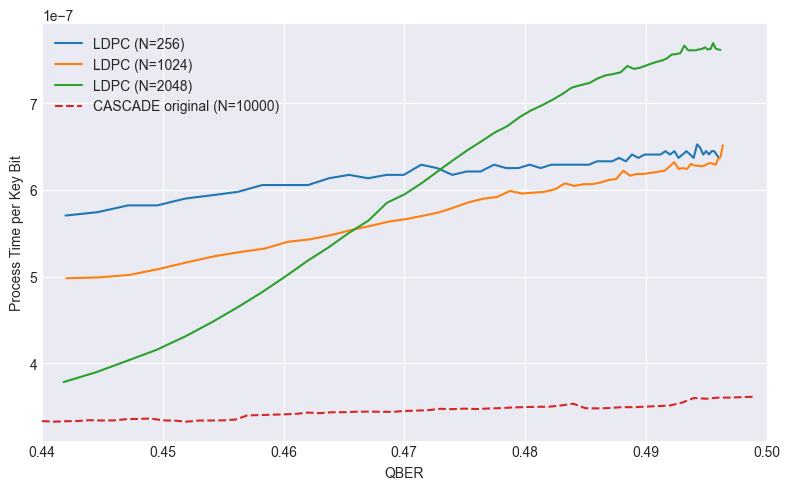

In [487]:
plot_vs_qber(
    [(df, "LDPC"), (df_cascade_verification_extended, "CASCADE original")],
    metric='process_time_per_bit',
    ylabel='Process Time per Key Bit',
    qber_range=(0.44, 0.5),
    color_by_keysize=True,
    show_band=False,
    marker=None,
)

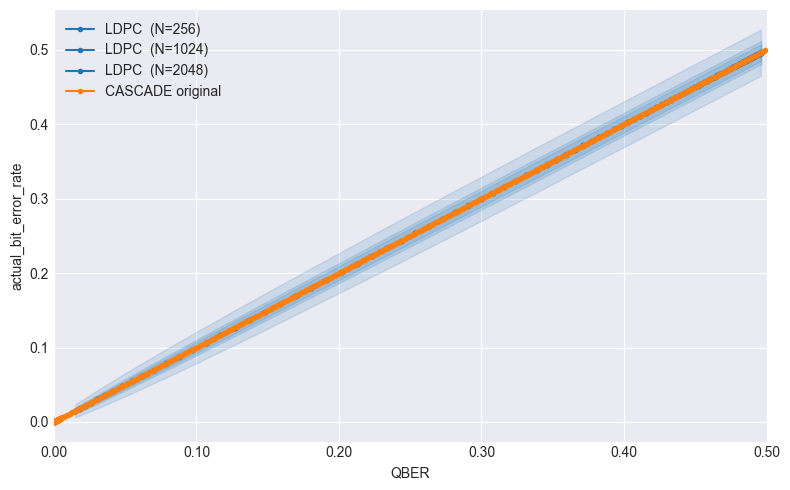

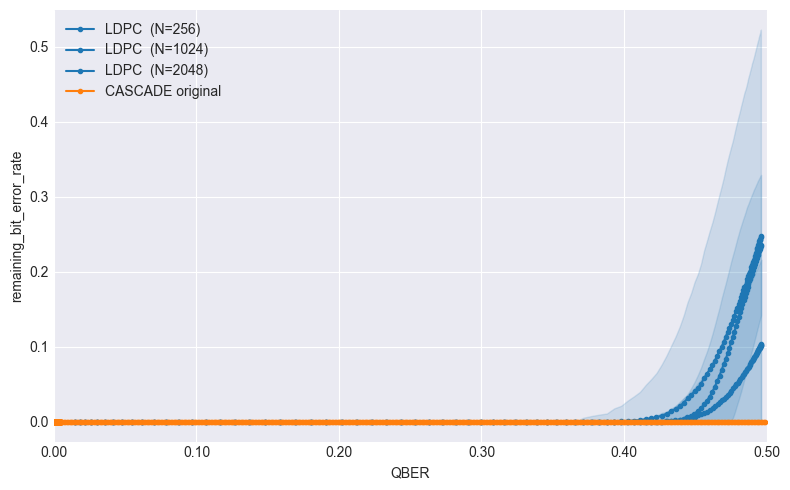

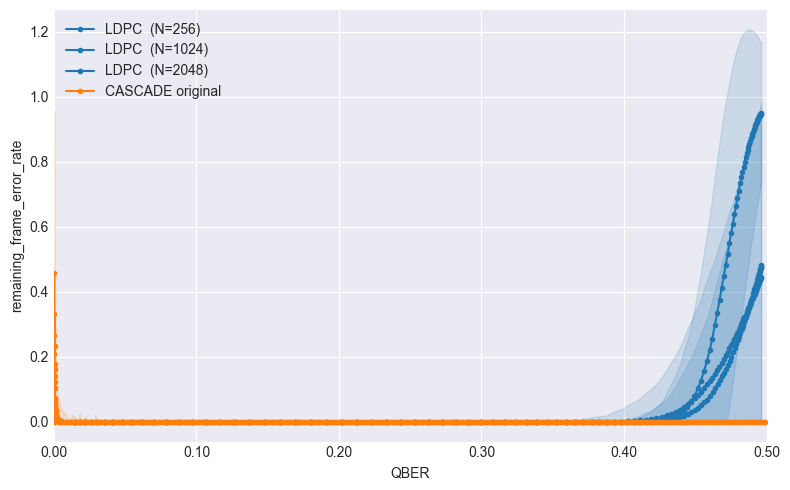

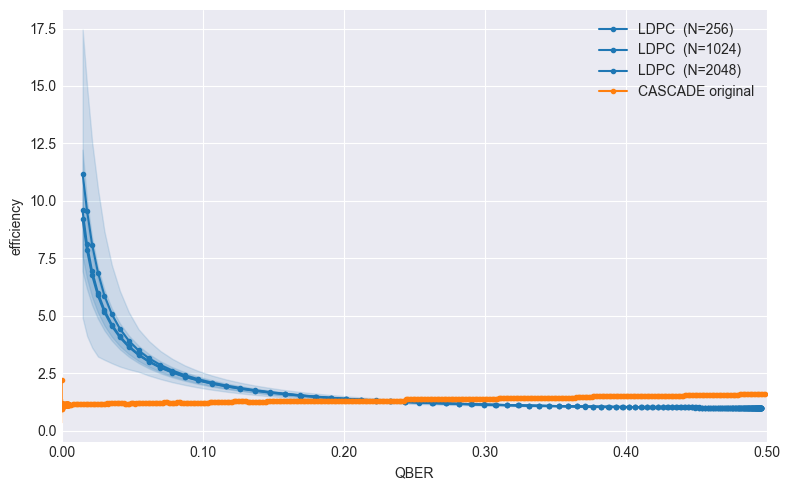

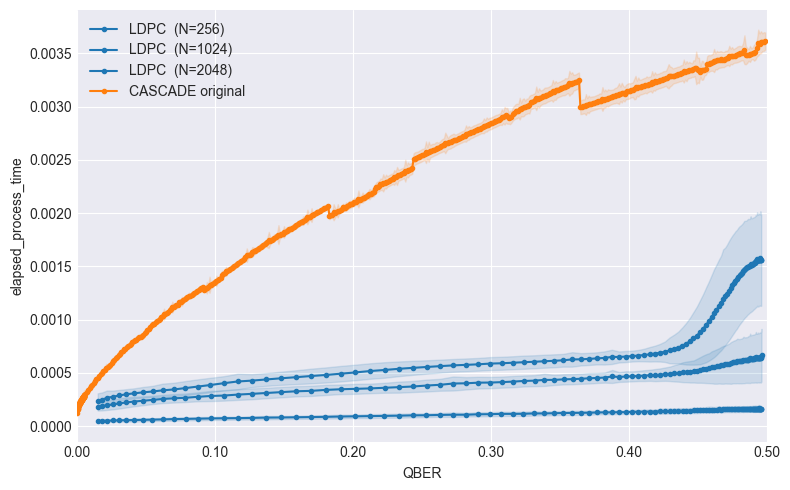

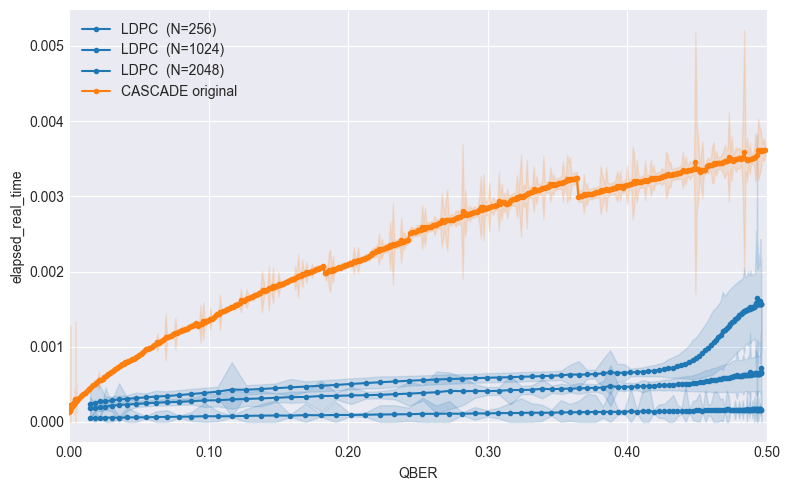

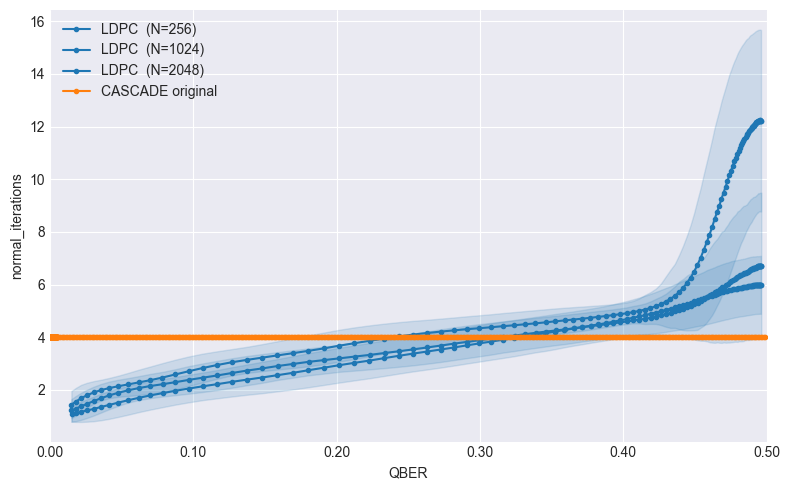

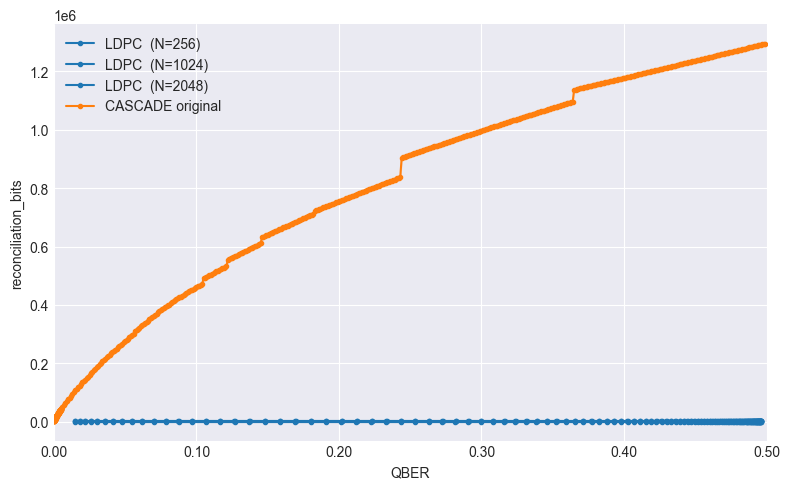

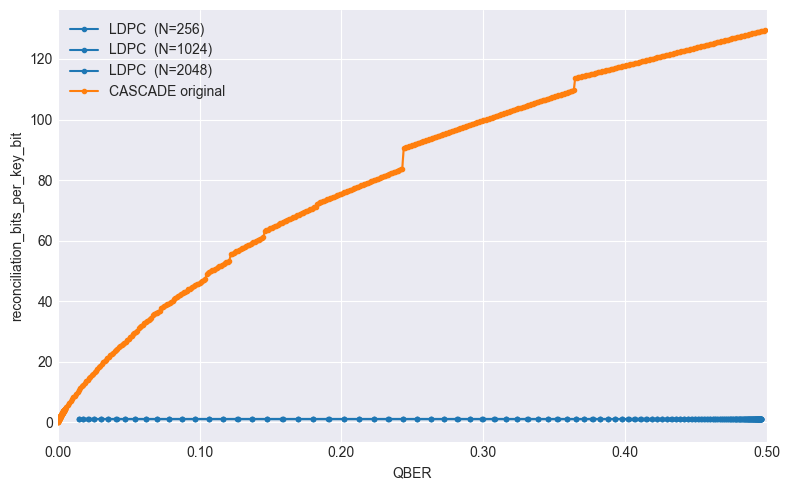

In [354]:
for m in metrics:
    plot_vs_qber(
        [(df, "LDPC"), (df_cascade_verification_extended, "CASCADE original")],
        metric=m,
        ylabel=m,
        qber_range=(0.00, 0.50),
    )

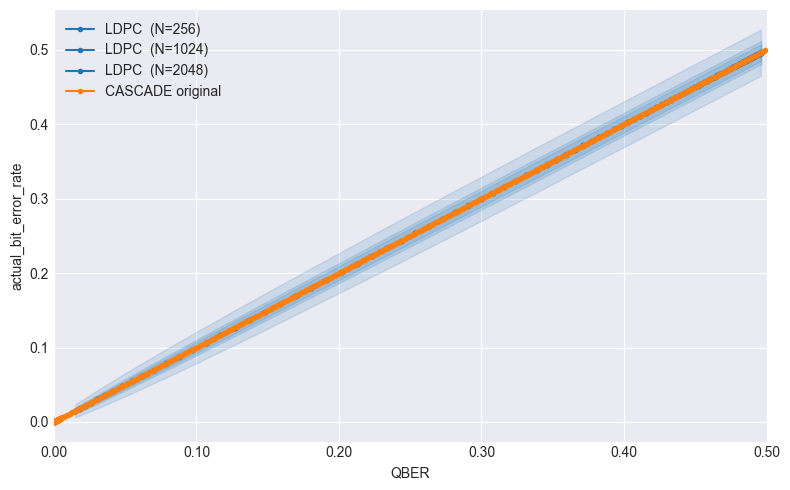

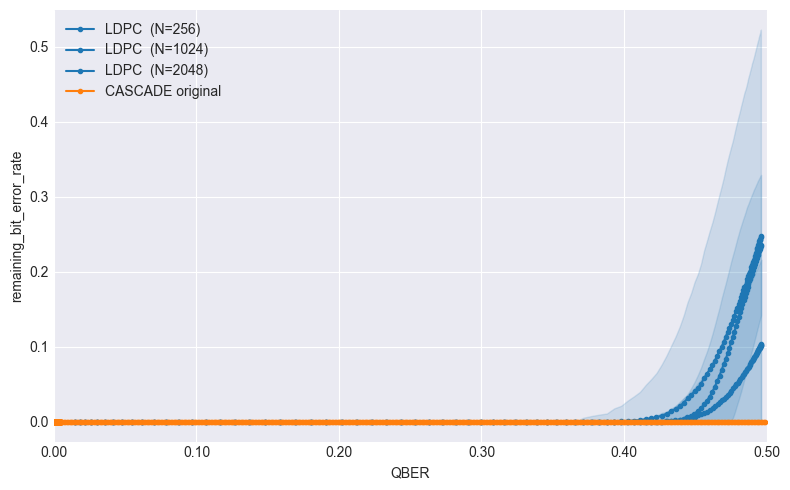

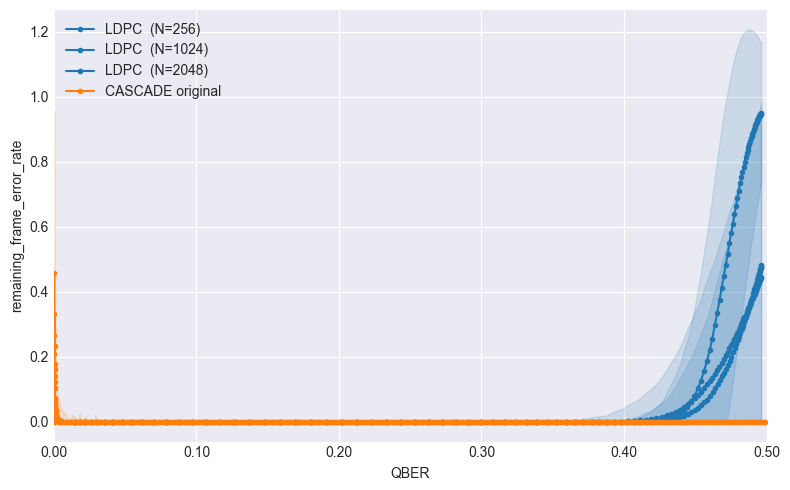

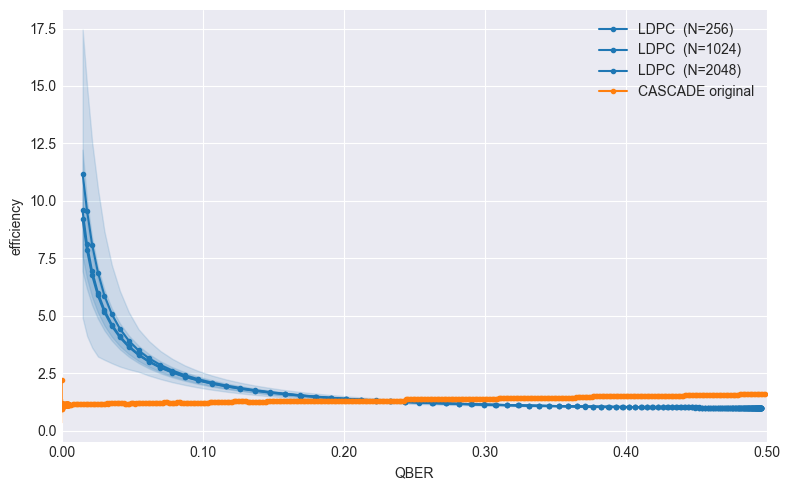

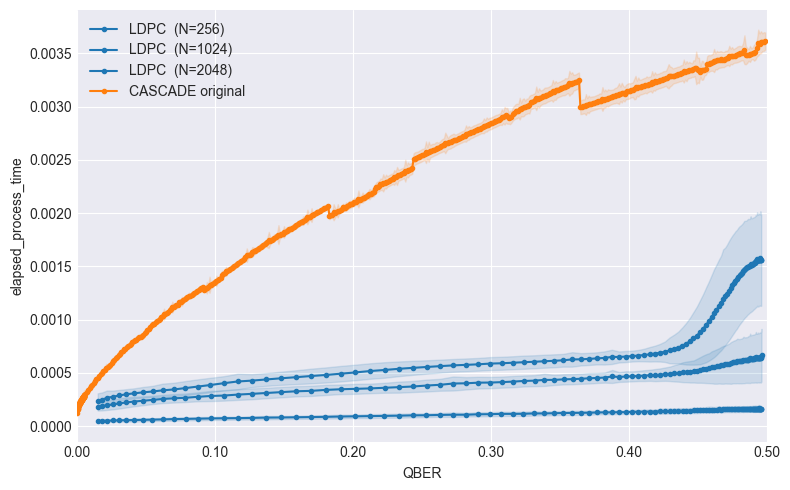

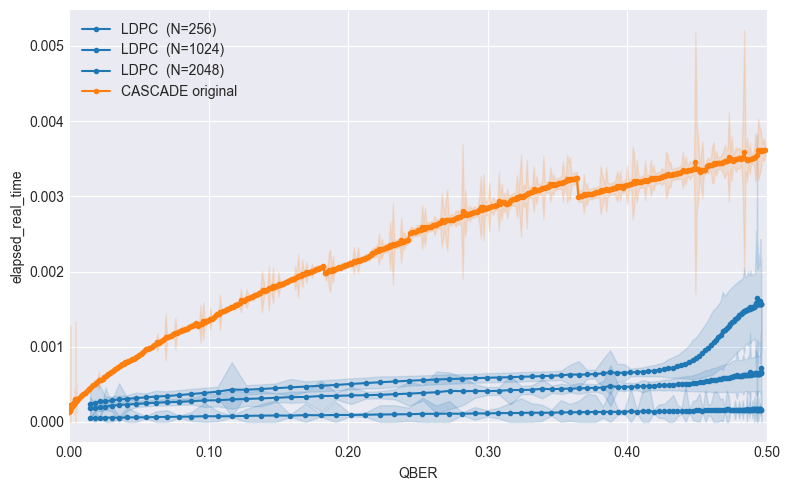

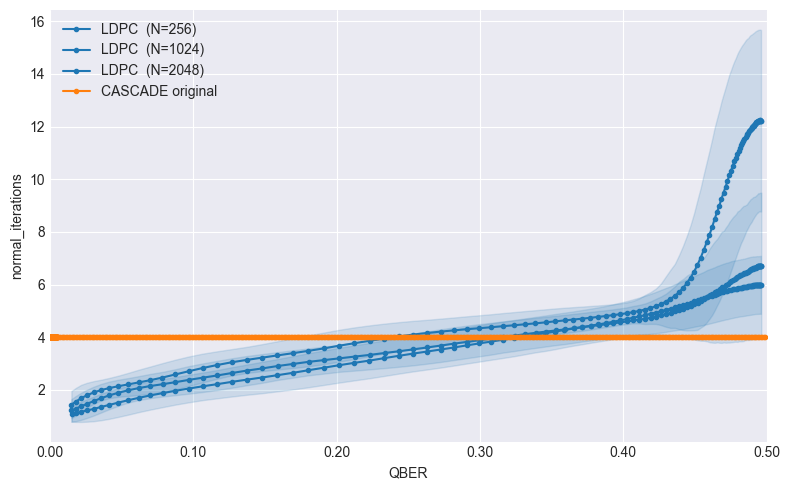

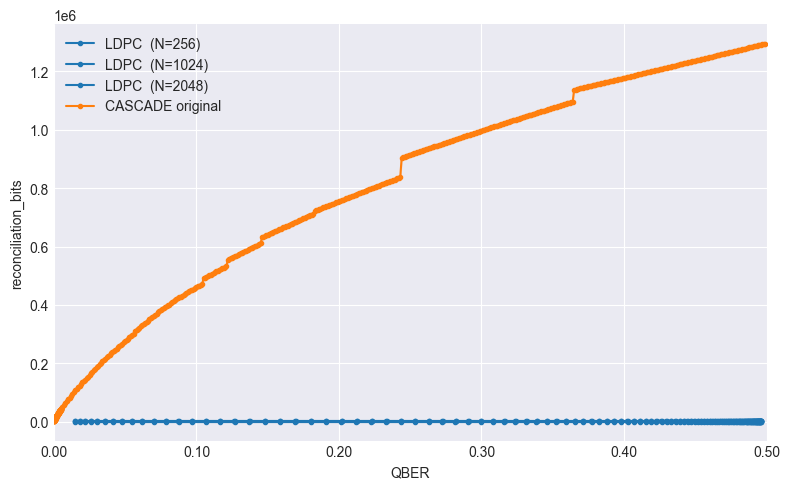

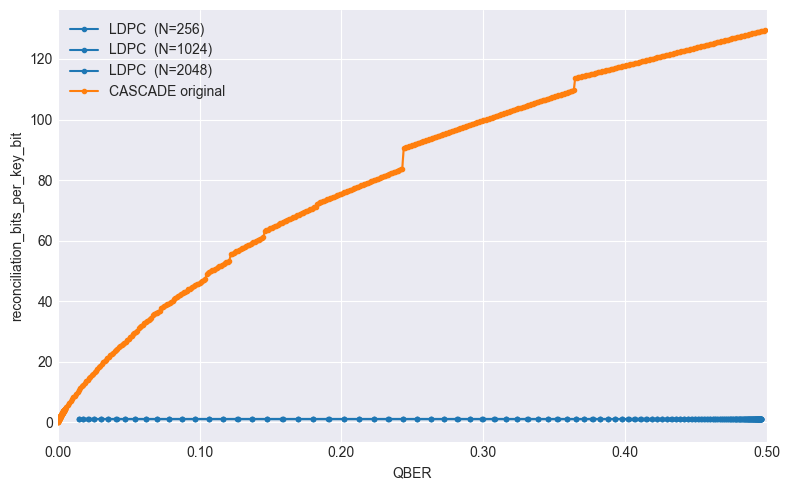

In [355]:
for m in metrics:
    plot_vs_qber(
        [(df, "LDPC"), (df_cascade_verification_extended, "CASCADE original")],
        metric=m,
        ylabel=m,
        qber_range=(0.00, 0.50),
    )

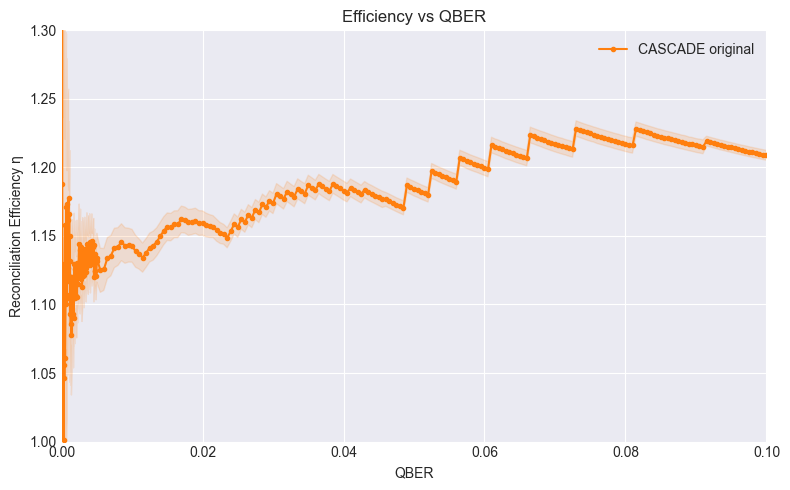

In [356]:
# Verification CASCADE plot Efficiency 
plot_vs_qber(
    [ (df[df["snr"] == 0.000100], 'LDPC'), (df_cascade_verification, "CASCADE original")],
    metric="efficiency",
    ylabel="Reconciliation Efficiency η",
    ylim=(1.0, 1.3),
    qber_range=(0.00, 0.1),
    title="Efficiency vs QBER",
)

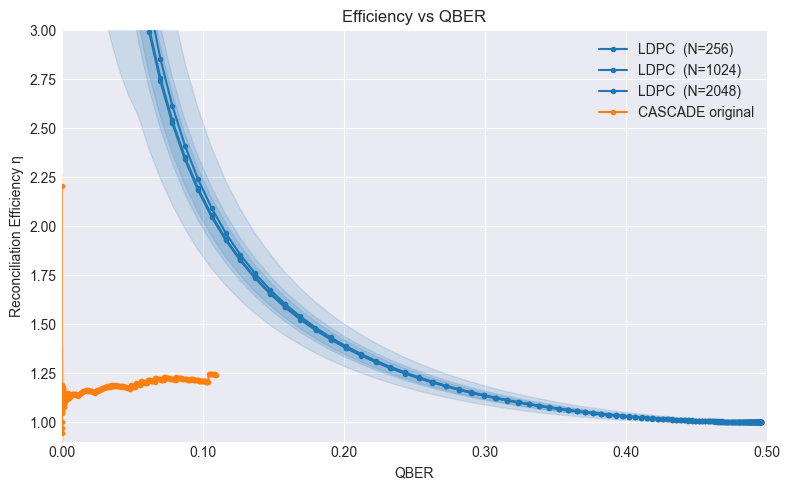

In [357]:
# Verification CASCADE vs LDPC Efficiency
plot_vs_qber(
    [ (df, 'LDPC'), (df_cascade_verification, "CASCADE original")],
    metric="efficiency",
    ylabel="Reconciliation Efficiency η",
    ylim=(0.9, 3.0),
    qber_range=(0.00, 0.5),
    title="Efficiency vs QBER",
)

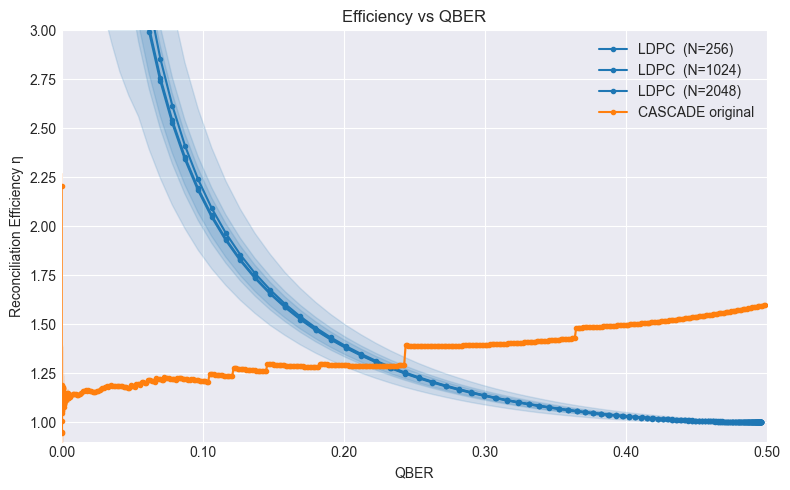

In [358]:
# Verification CASCADE vs LDPC Efficiency
plot_vs_qber(
    [ (df, 'LDPC'), (df_cascade_verification_extended, "CASCADE original")],
    metric="efficiency",
    ylabel="Reconciliation Efficiency η",
    ylim=(0.9, 3.0),
    qber_range=(0.00, 0.5),
    title="Efficiency vs QBER",
)

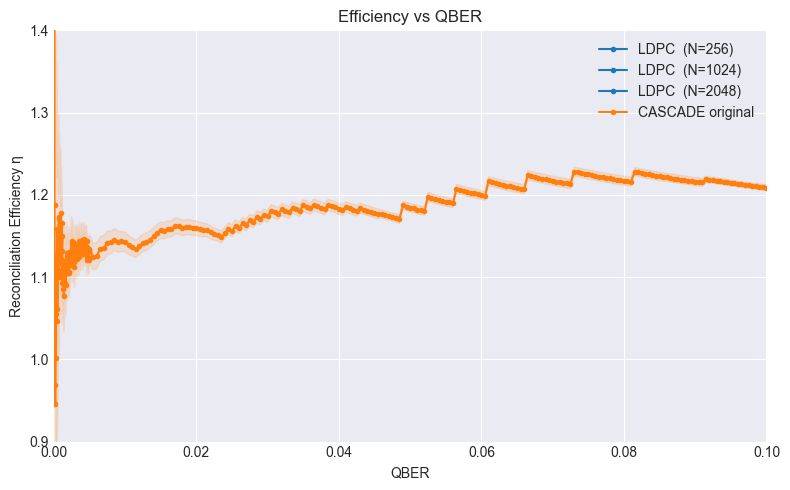

In [359]:
plot_vs_qber(
    [(df, "LDPC"), (df_cascade_verification, "CASCADE original")],
    metric="efficiency",
    ylabel="Reconciliation Efficiency η",
    ylim=(0.9, 1.4),
    qber_range=(0.00, 0.10),
    title="Efficiency vs QBER"
)

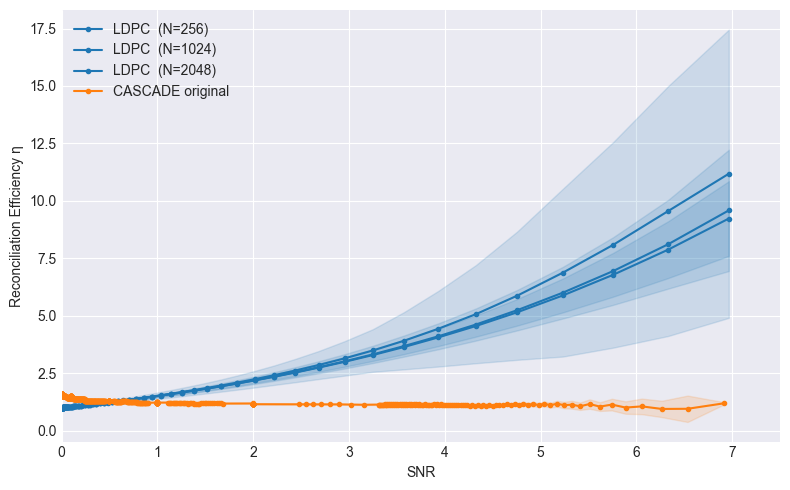

In [360]:
plot_vs_snr_linear(
    [(df, "LDPC"), (df_cascade_verification_extended, "CASCADE original")],
    metric="efficiency", ylabel="Reconciliation Efficiency η",
    snr_range=(0.0, 7.5)
)

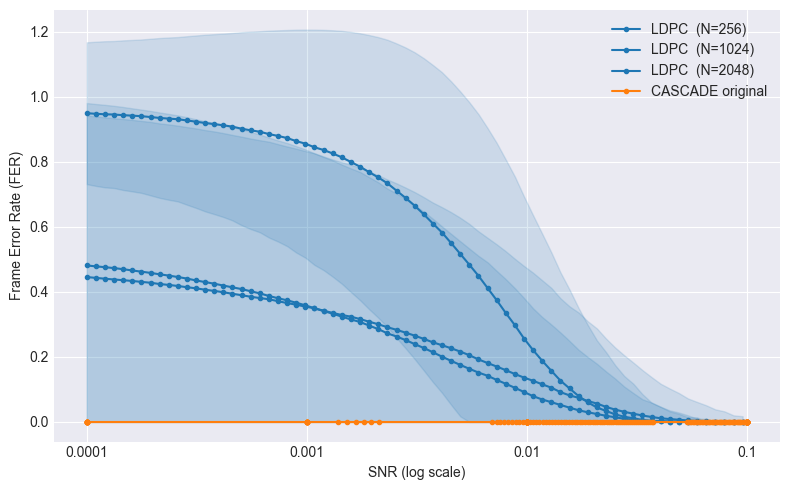

In [361]:
plot_vs_snr_log(
    [(df, "LDPC"), (df_cascade_verification_extended, "CASCADE original")],
    metric="remaining_frame_error_rate", ylabel="Frame Error Rate (FER)",
    snr_ticks=[0.0001, 0.001, 0.01, 0.1]
)
# def plot_vs_snr_log(series_list, metric, ylabel,
#                     snr_ticks=None, title=None,
#                     ylim=None, show_band=True, figsize=(8, 5)):

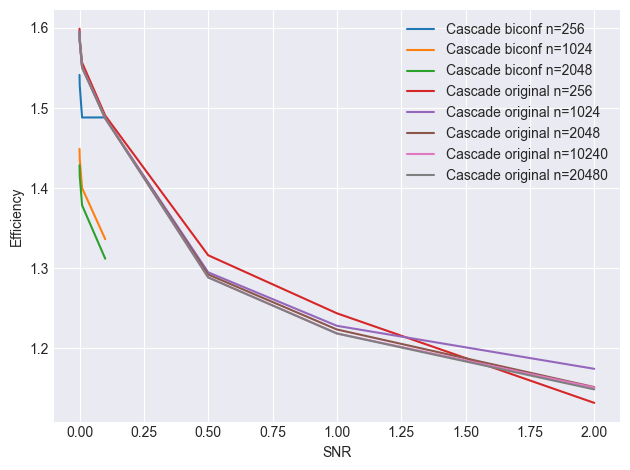

In [362]:
for (algo, keysize), subdf in df_cascade.groupby(["algorithm_name", "key_size"]):
    plt.plot(subdf["snr"], subdf["efficiency_avg"], label=f"Cascade {algo} n={keysize}")
plt.legend()
plt.xlabel("SNR")
plt.ylabel("Efficiency")
plt.tight_layout()
plt.show()


In [363]:
# plot_metric(df_cascade_original, "actual_bit_error_rate", "Actual BER")
# plot_metric(df_cascade_original, "efficiency", "Efficiency")
# plot_metric(df_cascade_original, "elapsed_real_time", "Elapsed Time")
# plot_metric(df_cascade_original, "normal_iterations", "Normal Iterations")
# plot_metric(df_cascade_original, "actual_bit_error_rate", "Actual BER")
# plot_metric(df_cascade_original, "remaining_bit_error_rate", "Remaining BER")
# plot_metric(df_cascade_original, "remaining_frame_error_rate", "Remaining FER")
# plot_metric(df_cascade_original, "efficiency", "Efficiency")
# plot_metric(df_cascade_original, "reconciliation_bits", "Reconciliation Bits")
# plot_metric(df_cascade_original, "reconciliation_bits_per_key_bit", "Reconciliation Bits per Key Bit")


In [364]:
# plot_metric(df, "remaining_bit_error_rate", "Remaining BER")

In [365]:
# df["1_minus_2ber_avg"] = 1 - 2 * df["remaining_bit_error_rate_avg"]
# df["1_minus_2ber_std"] = 2 * df["remaining_bit_error_rate_std"]  # if you need error bars
# plot_metric(df, "1_minus_2ber", "1 − 2×BER")

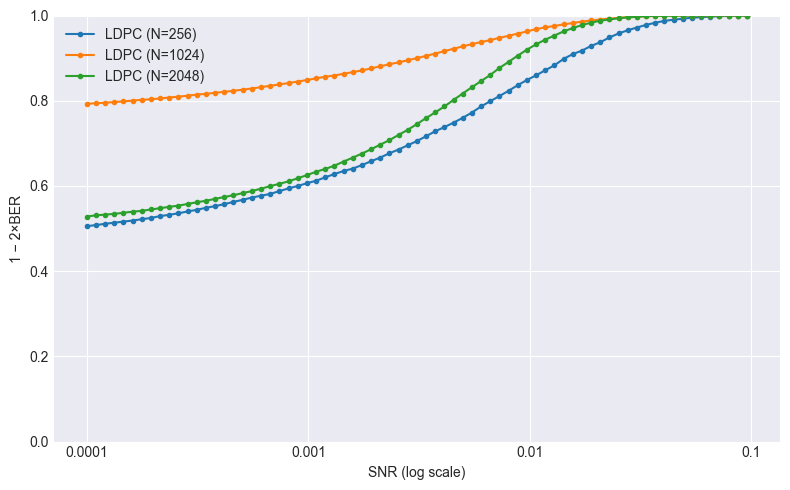

In [366]:
df["1_minus_2ber_avg"] = 1 - 2 * df["remaining_bit_error_rate_avg"]
df["1_minus_2ber_std"] = 2 * df["remaining_bit_error_rate_std"]  # if you need error bars
# plot_vs_snr_log(df, "1_minus_2ber", "1 − 2×BER")
plot_vs_snr_log(
    [(df, "LDPC")],
    metric="1_minus_2ber", ylabel="1 − 2×BER",
    snr_ticks=[0.0001, 0.001, 0.01, 0.1],
    ylim=(0.0, 1.0),
    show_band=False,
    color_by_keysize=True,
)

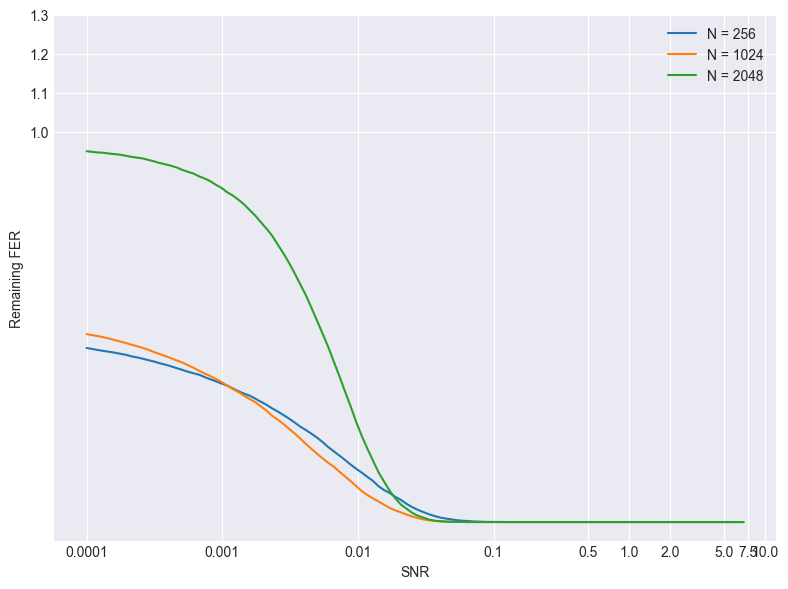

In [367]:
plot_metric(df, "remaining_frame_error_rate", "Remaining FER")

In [368]:
# plot_metric(df, "efficiency", "Efficiency")
# plot_metric(df, "elapsed_real_time", "Elapsed Time")
# plot_metric(df, "normal_iterations", "Normal Iterations")
# plot_metric(df, "actual_bit_error_rate", "Actual BER")
# plot_metric(df, "remaining_bit_error_rate", "Remaining BER")
# plot_metric(df, "remaining_frame_error_rate", "Remaining FER")
# plot_metric(df, "efficiency", "Efficiency")
# plot_metric(df, "reconciliation_bits", "Reconciliation Bits")
# plot_metric(df, "reconciliation_bits_per_key_bit", "Reconciliation Bits per Key Bit")